Training sgd...
sgd - Final W: [ 1.9252175 -3.5501237], b: 3.8666
sgd - Final Loss: 0.009827

Training minibatch...
minibatch - Final W: [ 1.92592089 -3.54904233], b: 3.8677
minibatch - Final Loss: 0.009838

Training momentum...
momentum - Final W: [ 1.9285253  -3.54401605], b: 3.8715
momentum - Final Loss: 0.009628

Training nesterov...
nesterov - Final W: [ 1.9272603  -3.54240472], b: 3.8700
nesterov - Final Loss: 0.009653

Training adagrad...
adagrad - Final W: [ 1.92494007 -3.54904249], b: 3.8677
adagrad - Final Loss: 0.009904

Training adam...
adam - Final W: [ 1.95014414 -3.56642226], b: 3.8845
adam - Final Loss: 0.010729



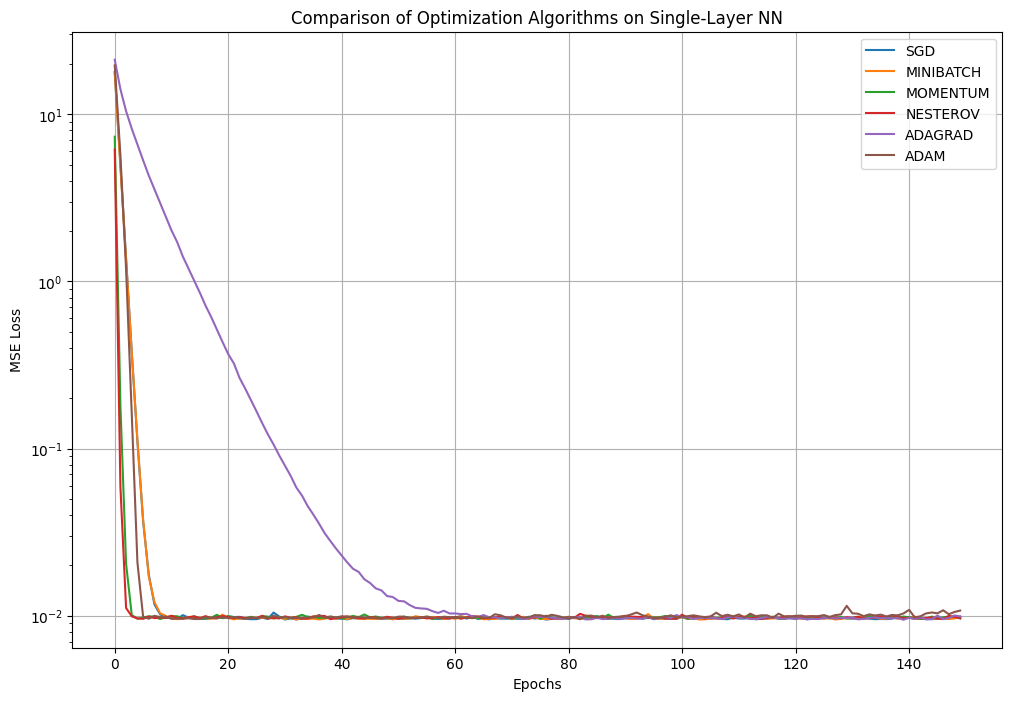

True W: [ 2.  -3.5], True b: 4.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1. Generate Synthetic Dataset (Single-Layer Learnable Task)
# ----------------------------
np.random.seed(42)
m = 1000  # samples
X = np.random.randn(m, 2)  # 2 features
true_W = np.array([[2.0], [-3.5]])  # true weights
true_b = 4.0
y = X @ true_W + true_b + 0.1 * np.random.randn(m, 1)  # add small noise

# Normalize features (optional but helps all optimizers)
X = (X - X.mean(axis=0)) / X.std(axis=0)

# ----------------------------
# 2. Single-Layer Neural Network Class with Multiple Optimizers
# ----------------------------
class SingleLayerNN:
    def __init__(self, input_dim, output_dim=1):
        self.W = np.random.randn(input_dim, output_dim) * 0.01
        self.b = np.zeros((1, output_dim))

        # Optimizer state variables
        self.v_W, self.v_b = 0, 0          # Momentum / Nesterov
        self.cache_W, self.cache_b = 0, 0  # AdaGrad
        self.m_W, self.m_b = 0, 0          # Adam mean
        self.v_W_adam, self.v_b_adam = 0, 0 # Adam variance
        self.t = 0                         # Adam time step

    def forward(self, X):
        return X @ self.W + self.b

    def compute_gradients(self, X, y, y_pred):
        m = X.shape[0]
        dW = (2/m) * X.T @ (y_pred - y)
        db = (2/m) * np.sum(y_pred - y, axis=0, keepdims=True)
        return dW, db

    def update_sgd(self, dW, db, lr=0.01):
        self.W -= lr * dW
        self.b -= lr * db

    def update_minibatch(self, dW, db, lr=0.01):
        # Same as SGD, but the gradient is already computed on a mini-batch
        self.W -= lr * dW
        self.b -= lr * db

    def update_momentum(self, dW, db, lr=0.01, beta=0.9):
        self.v_W = beta * self.v_W - lr * dW
        self.v_b = beta * self.v_b - lr * db
        self.W += self.v_W
        self.b += self.v_b

    def update_nesterov(self, dW, db, lr=0.01, beta=0.9):
        # Standard Nesterov formulation
        v_prev_W = self.v_W
        v_prev_b = self.v_b
        self.v_W = beta * self.v_W - lr * dW
        self.v_b = beta * self.v_b - lr * db
        self.W += -beta * v_prev_W + (1 + beta) * self.v_W
        self.b += -beta * v_prev_b + (1 + beta) * self.v_b

    def update_adagrad(self, dW, db, lr=0.01, eps=1e-8):
        self.cache_W += dW**2
        self.cache_b += db**2
        self.W -= lr * dW / (np.sqrt(self.cache_W) + eps)
        self.b -= lr * db / (np.sqrt(self.cache_b) + eps)

    def update_adam(self, dW, db, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        # Update biased moments
        self.m_W = beta1 * self.m_W + (1 - beta1) * dW
        self.m_b = beta1 * self.m_b + (1 - beta1) * db
        self.v_W_adam = beta2 * self.v_W_adam + (1 - beta2) * (dW**2)
        self.v_b_adam = beta2 * self.v_b_adam + (1 - beta2) * (db**2)
        # Bias correction
        m_hat_W = self.m_W / (1 - beta1**self.t)
        m_hat_b = self.m_b / (1 - beta1**self.t)
        v_hat_W = self.v_W_adam / (1 - beta2**self.t)
        v_hat_b = self.v_b_adam / (1 - beta2**self.t)
        # Update
        self.W -= lr * m_hat_W / (np.sqrt(v_hat_W) + eps)
        self.b -= lr * m_hat_b / (np.sqrt(v_hat_b) + eps)

# ----------------------------
# 3. Training Function
# ----------------------------
def train_optimizer(optimizer_name, X, y, epochs=100, batch_size=32, lr=0.1):
    model = SingleLayerNN(input_dim=X.shape[1])
    losses = []

    for epoch in range(epochs):
        # Shuffle data for stochastic/mini-batch
        indices = np.random.permutation(len(X))
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        epoch_loss = 0
        num_batches = 0

        # Mini-batch loop
        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            y_pred = model.forward(X_batch)
            dW, db = model.compute_gradients(X_batch, y_batch, y_pred)

            # Apply selected optimizer update
            if optimizer_name == 'sgd':
                model.update_sgd(dW, db, lr)
            elif optimizer_name == 'minibatch':
                model.update_minibatch(dW, db, lr)
            elif optimizer_name == 'momentum':
                model.update_momentum(dW, db, lr)
            elif optimizer_name == 'nesterov':
                model.update_nesterov(dW, db, lr)
            elif optimizer_name == 'adagrad':
                model.update_adagrad(dW, db, lr)
            elif optimizer_name == 'adam':
                model.update_adam(dW, db, lr)

            # Compute loss for this batch
            loss = np.mean((y_pred - y_batch)**2)
            epoch_loss += loss
            num_batches += 1

        losses.append(epoch_loss / num_batches)

    return model, losses

# ----------------------------
# 4. Compare All Optimizers
# ----------------------------
optimizers = ['sgd', 'minibatch', 'momentum', 'nesterov', 'adagrad', 'adam']
results = {}
epochs = 150

plt.figure(figsize=(12, 8))

for opt in optimizers:
    print(f"Training {opt}...")
    # Tune learning rates for fair comparison (Adam is usually more tolerant)
    if opt == 'adam':
        lr = 0.05
    elif opt == 'adagrad':
        lr = 0.1
    else:
        lr = 0.01

    model, losses = train_optimizer(opt, X, y, epochs=epochs, batch_size=32, lr=lr)
    results[opt] = losses

    # Print final parameters
    print(f"{opt} - Final W: {model.W.flatten()}, b: {model.b[0][0]:.4f}")
    print(f"{opt} - Final Loss: {losses[-1]:.6f}\n")

    plt.plot(losses, label=opt.upper())

plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Comparison of Optimization Algorithms on Single-Layer NN')
plt.legend()
plt.grid(True)
plt.yscale('log')  # log scale to see differences clearly
plt.show()

# ----------------------------
# 5. Print True Parameters for Reference
# ----------------------------
print(f"True W: {true_W.flatten()}, True b: {true_b}")